In [3]:
import logging
import os
import sys
from io import BytesIO
import pandas as pd
import requests
from datetime import date, timedelta, datetime
from collections import Counter
import numpy as np
import json
#from astroquery.vizier import Vizier
import astropy.units as u
from astropy.coordinates import SkyCoord
from tqdm import tqdm
import time
from astropy.table import Table, Column
from matplotlib import pyplot as plt

In [4]:
from desimodel.footprint import is_point_in_desi

In [5]:
import json
import requests
from typing import Any, Dict, List, Optional

from astropy.time import Time

In [6]:
now = datetime.now()
now.isoformat()

'2026-06-02T08:18:54.239164'

In [ ]:
# ---- CONFIG ----
API_URL = "https://api.kaboom.caltech.edu/auth"
USERNAME = "xhall"
PASSWORD = "YOUR_SECRET_PASSWORD"  # your password, or better yet, read from env var or file
CLIENT_TOKEN = "YOUR_SECRET_TOKEN"  # the Bearer token shown in the docs

# ---- REQUEST ----
headers = {
    "Content-Type": "application/x-www-form-urlencoded",
    "Authorization": f"Bearer {CLIENT_TOKEN}",
}

data = {
    "username": USERNAME,
    "password": PASSWORD,
}

resp = requests.post(API_URL, headers=headers, data=data)

# ---- HANDLE RESPONSE ----
resp.raise_for_status()  # raises if 400/401/etc

token_info = resp.json()
ACCESS_TOKEN = token_info["access_token"]

print("Access token:", ACCESS_TOKEN)
print("Token type:", token_info.get("token_type"))
print("Expires in:", token_info.get("expires_in"))

In [8]:
KABOOM_BASE_URL = "https://api.kaboom.caltech.edu"

def kaboom_filters_test(
    *,
    token: str,
    pipeline: List[Dict[str, Any]],
    survey: str = "LSST",
    days_back: float = 7.0,
    end_jd: Optional[float] = None,
    start_jd: Optional[float] = None,
    limit: Optional[int] = None,
    sort_by: Optional[str] = None,
    sort_order: str = "Descending",   # enum in docs: Ascending / Descending
    permissions: Optional[Dict[str, Any]] = None,
    base_url: str = KABOOM_BASE_URL,
    timeout_s: int = 300,
) -> Dict[str, Any]:
    """
    Run a filter pipeline test over a JD range via POST /filters/test.

    Returns the full JSON response, typically:
      { "pipeline": [...], "results": [...] }
    """
    if permissions is None:
        # Permissions must be an OBJECT (map). {} usually works for owner-only.
        permissions = {}

    if end_jd is None:
        end_jd = Time.now().jd
    if start_jd is None:
        start_jd = end_jd - float(days_back)

    print(start_jd, end_jd)

    url = f"{base_url.rstrip('/')}/filters/test"
    headers = {
        "Authorization": f"Bearer {token}",
        "Content-Type": "application/json",
        "Accept": "application/json",
    }

    payload: Dict[str, Any] = {
        "pipeline": pipeline,
        "survey": survey,
        "permissions": permissions,
        "start_jd": start_jd,
        "end_jd": end_jd,
        "limit": limit,
        "sort_by": sort_by,
        "sort_order": sort_order,
        # these are optional; omit by default
        # "candids": None,
        # "object_ids": None,
    }

    # Drop nulls to match the docs' style
    payload = {k: v for k, v in payload.items() if v is not None}

    resp = requests.post(url, headers=headers, json=payload, timeout=timeout_s)
    if resp.status_code >= 400:
        try:
            detail = resp.json()
        except Exception:
            detail = resp.text
        raise RuntimeError(f"POST /filters/test failed: HTTP {resp.status_code}\nResponse: {detail}")

    return resp.json()


In [10]:
PIPELINE = [
  {
    "$project": {
      "candidate.ra": 1,
      "candidate.dec": 1,
      "candidate.jd": 1,
      "candidate.isDipole": 1,
      "candidate.isdiffpos": 1,
      "candidate.magpsf": 1,
      "candidate.ndethist": 1,
      "candidate.reliability": 1,
      "cross_matches.LSPSC": 1,
      "distance_arcsec": 1,
      "mag_white": 1,
      "properties.near_brightstar": 1,
      "properties.rock": 1,
      "properties.star": 1,
      "properties.stationary": 1,
      "score": 1,
      "objectId": 1
    }
  },
  {
    "$match": {
      "$and": [
        {
          "$and": [
            { "candidate.magpsf": { "$lte": 22 } },
            { "candidate.isdiffpos": { "$in": [True] } },
            { "candidate.reliability": { "$gt": 0.7 } },
            { "candidate.isDipole": { "$in": [False] } },
            { "candidate.ndethist": { "$gte": 2 } },
            { "candidate.dec": { "$gt": -30 } }
          ]
        },
        {
          "$and": [
            {
              "$and": [
                { "properties.rock": { "$in": [False] } },
                { "properties.star": { "$in": [False] } },
                { "properties.near_brightstar": { "$in": [False] } },
                { "properties.stationary": { "$in": [True] } }
              ]
            },
            {
              "$expr": {
                "$not": {
                  "$anyElementTrue": {
                    "$map": {
                      "input": { "$ifNull": ["$cross_matches.LSPSC", []] },
                      "in": {
                        "$and": [
                          { "$gte": ["$$this.score", 0.7] },
                          {
                            "$or": [
                              { "$and": [
                                  { "$lte": ["$$this.distance_arcsec", 4] },
                                  { "$lte": ["$$this.mag_white", 18] }
                                ]
                              },
                              { "$and": [
                                  { "$lte": ["$$this.distance_arcsec", 10] },
                                  { "$lte": ["$$this.mag_white", 16] }
                                ]
                              },
                              { "$and": [
                                  { "$lte": ["$$this.distance_arcsec", 30] },
                                  { "$lte": ["$$this.mag_white", 15] }
                                ]
                              },
                              { "$and": [
                                  { "$lte": ["$$this.distance_arcsec", 6] },
                                  { "$lte": ["$$this.mag_white", 17.5] }
                                ]
                              }
                            ]
                          }
                        ]
                      }
                    }
                  }
                }
              }
            }
          ]
        }
      ]
    }
  },
  {
    "$project": {
      "objectId": 1,
      "candidate.ra": 1,
      "candidate.dec": 1,
      "candidate.jd": 1,
      "candidate.isDipole": 1,
      "candidate.isdiffpos": 1,
      "candidate.magpsf": 1,
      "candidate.ndethist": 1,
      "candidate.reliability": 1,
      "cross_matches.LSPSC": 1,
      "distance_arcsec": 1,
      "mag_white": 1,
      "properties.near_brightstar": 1,
      "properties.rock": 1,
      "properties.star": 1,
      "properties.stationary": 1,
      "score": 1
    }
  }
]

In [11]:
resp = kaboom_filters_test(token=ACCESS_TOKEN, pipeline=PIPELINE, survey="LSST", days_back=7, sort_by="candidate.jd", sort_order="Descending")
data = resp.get("data", [])

2461187.1383197717 2461194.1383197717


In [12]:
LSST_alerts = pd.json_normalize(data["results"])

In [13]:
LSST_alerts

,_id,objectId,candidate.ra,candidate.dec,candidate.reliability,candidate.isDipole,candidate.jd,candidate.magpsf,candidate.isdiffpos,candidate.ndethist,properties.rock,properties.stationary,properties.star,properties.near_brightstar,cross_matches.LSPSC
0,170477097793355821,170468319192154115,189.006669,8.602388,1.000000,False,2.461193e+06,18.665482,True,2,False,True,False,False,"[{'_id': 10995514673728726, 'ra': 189.00581359..."
1,170477092891787380,170411112000913487,151.163543,2.507445,1.000000,False,2.461192e+06,19.647713,True,45,False,True,False,False,"[{'_id': 10995478426561740, 'ra': 151.16284179..."
2,170477092898603049,313875416793743402,149.813398,3.271527,1.000000,False,2.461192e+06,20.876848,True,1193,False,True,False,False,"[{'_id': 10995482950114663, 'ra': 149.81336975..."
3,170477092873961543,313853517419249797,149.444079,2.548383,1.000000,False,2.461192e+06,20.836739,True,1384,False,True,False,False,"[{'_id': 10995478419225058, 'ra': 149.44407653..."
4,170477092903846044,170270398384963595,149.850432,3.703854,1.000000,False,2.461192e+06,21.311794,True,82,False,True,False,False,"[{'_id': 10995485965822265, 'ra': 149.85032653..."
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
322,170455093597962258,313985345684242460,150.303287,3.565036,0.999746,False,2.461187e+06,21.290258,True,1172,False,True,False,False,"[{'_id': 10995484460063672, 'ra': 150.30329895..."
323,170455093620506679,170261592629837872,151.134196,3.315050,0.997285,False,2.461187e+06,21.211746,True,61,False,True,False,False,"[{'_id': 10995482955360682, 'ra': 151.13439941..."
324,170455093601107979,313853517409288214,150.702193,3.315401,0.995791,False,2.461187e+06,21.661201,True,1367,False,True,False,False,"[{'_id': 10995482953270719, 'ra': 150.70220947..."
325,170455093611593742,313853517579157648,150.327421,2.460860,0.912326,False,2.461187e+06,21.892834,True,1345,False,True,False,False,"[{'_id': 10995478423410649, 'ra': 150.32740783..."


In [10]:
COSMOS_ra, COSMOS_dec = 150.11, 2.23

In [11]:
# center of the pointing
center = SkyCoord(COSMOS_ra*u.deg, COSMOS_dec*u.deg, frame="icrs")

# alerts -> SkyCoord
c = SkyCoord(LSST_alerts["candidate.ra"].to_numpy()*u.deg,
             LSST_alerts["candidate.dec"].to_numpy()*u.deg,
             frame="icrs")

# within 5 deg
sep = c.separation(center)
mask = sep <= 5*u.deg

LSST_alerts_5deg = LSST_alerts.loc[mask].copy()
LSST_alerts_5deg["sep_deg"] = sep[mask].to_value(u.deg)  # optional: keep separation

In [12]:
LSST_alerts_5deg_sorted = (
    LSST_alerts_5deg
      .sort_values(["candidate.jd", "candidate.magpsf"], ascending=[False, True])
      .drop_duplicates(subset="objectId", keep="first")
      .reset_index(drop=True)
)
len(LSST_alerts_5deg_sorted)

41

In [13]:
LSST_alerts_5deg_sorted_bright = LSST_alerts_5deg_sorted.loc[LSST_alerts_5deg_sorted["candidate.magpsf"] < 22.5]

In [14]:
LSST_alerts_5deg_sorted_bright["candidate.jd"]

0     2.461173e+06
1     2.461173e+06
2     2.461173e+06
3     2.461173e+06
4     2.461173e+06
5     2.461173e+06
6     2.461173e+06
7     2.461173e+06
8     2.461173e+06
9     2.461173e+06
10    2.461173e+06
11    2.461173e+06
12    2.461173e+06
13    2.461173e+06
14    2.461173e+06
15    2.461173e+06
16    2.461173e+06
17    2.461173e+06
18    2.461173e+06
19    2.461173e+06
20    2.461173e+06
21    2.461173e+06
22    2.461173e+06
23    2.461173e+06
24    2.461173e+06
25    2.461173e+06
26    2.461173e+06
27    2.461173e+06
28    2.461173e+06
29    2.461173e+06
30    2.461173e+06
31    2.461173e+06
32    2.461173e+06
33    2.461173e+06
34    2.461173e+06
35    2.461173e+06
36    2.461173e+06
37    2.461173e+06
38    2.461173e+06
39    2.461173e+06
40    2.461173e+06
Name: candidate.jd, dtype: float64

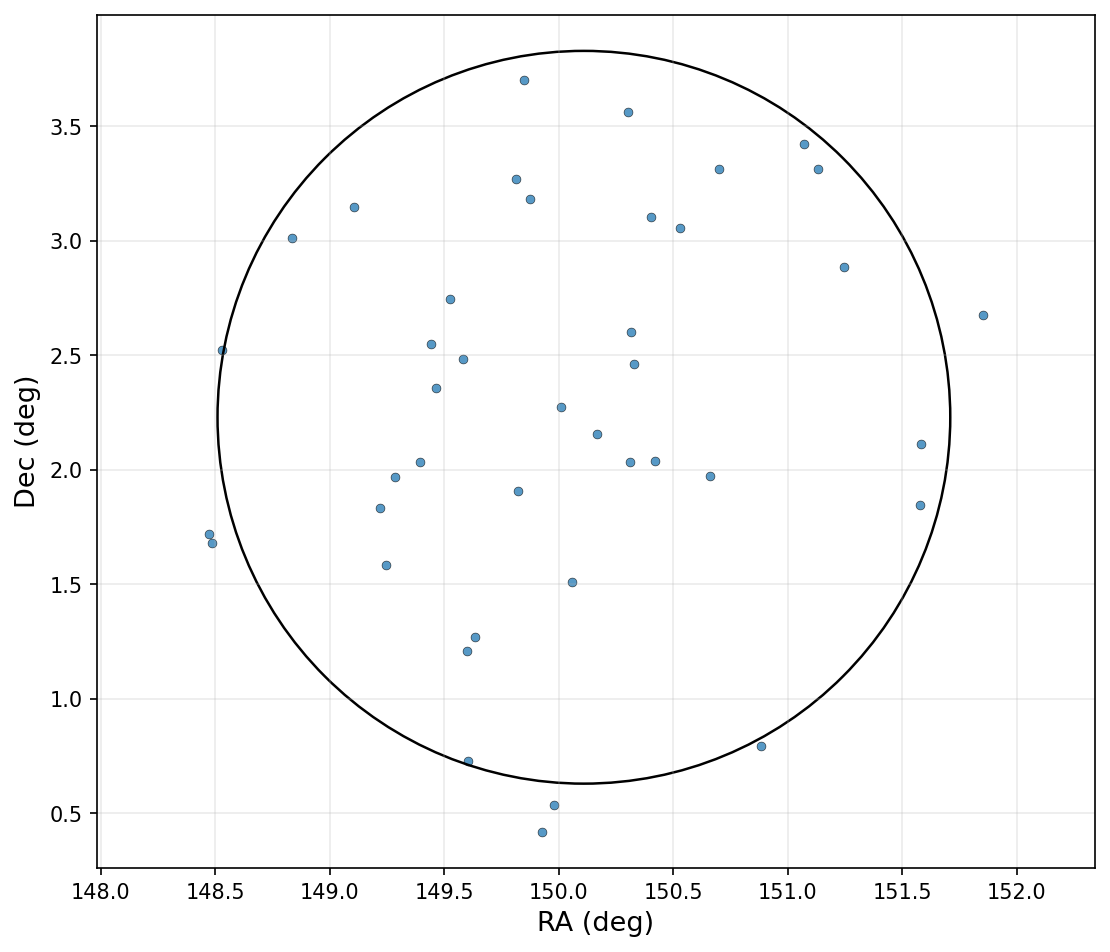

In [15]:
fig, ax = plt.subplots(figsize=(7.5, 6.5), dpi=150)

ax.scatter(
    LSST_alerts_5deg_sorted_bright["candidate.ra"],
    LSST_alerts_5deg_sorted_bright["candidate.dec"],
    s=18,
    alpha=0.75,
    edgecolors="k",
    linewidths=0.3,
)

# optional: show your COSMOS pointing + 5° circle
#ax.scatter([COSMOS_ra], [COSMOS_dec], marker="*", s=220, edgecolors="k", linewidths=0.6)
circ = plt.Circle((COSMOS_ra, COSMOS_dec), 1.6, fill=False, linewidth=1.2)
ax.add_patch(circ)

ax.set_xlabel("RA (deg)", fontsize=13)
ax.set_ylabel("Dec (deg)", fontsize=13)
#ax.set_title("LSST alerts within 5° of COSMOS", fontsize=14)

ax.grid(True, alpha=0.25)
ax.set_aspect("equal", adjustable="datalim")  # keeps angles sensible

plt.tight_layout()
plt.show()

In [16]:
len(LSST_alerts_5deg_sorted_bright)

41

In [17]:
table = Table(
    names=("name", "ra", "declination", "reporting_group", "reporters", "creationdate", "lastmodified"),
    dtype=("U25", "f8", "f8", "U50", "U50", "U25", "U25")  # Integer, float, and string column types
)

reporter = "Xander"
reporter_group = "LSST"

for row in LSST_alerts_5deg_sorted_bright.iterrows():
    row = row[1]
    new_row = [row["objectId"], row["candidate.ra"], row["candidate.dec"], reporter_group, reporter, now.isoformat().replace("T", " "), now.isoformat().replace("T", " ")]
    table.add_row(new_row)

In [18]:
table.to_pandas().to_csv("LSST_ToO/ToO_LSST-{}{:02d}{:02d}.csv".format(now.date().year, now.date().month, now.date().day), index = False)

In [19]:
# ---------- RA/DEC bitmap encoding ----------
def radec_to_bitmap(ra_deg, dec_deg):
    """
    Pack RA/DEC into a 64-bit int:
      [RA:32 bits][DEC_sign:1 bit][|DEC|:31 bits]

    Assumed fixed-point mapping (you can change scalings if you have a spec):
      RA in [0,360) -> uint32 via floor(ra/360 * 2^32)
      |DEC| in [0,90] -> uint31 via floor(|dec|/90 * (2^31-1))
      DEC_sign bit: 1 if dec < 0 else 0
    """
    ra = np.asarray(ra_deg, dtype=np.float64)
    dec = np.asarray(dec_deg, dtype=np.float64)

    # Normalize RA into [0, 360)
    ra = np.mod(ra, 360.0)

    # Scale to unsigned 32-bit
    ra_u32 = np.floor(ra / 360.0 * (2**16)).astype(np.uint64)
    ra_u32 = np.clip(ra_u32, 0, 2**16 - 1).astype(np.uint64)

    # DEC sign + magnitude
    sign = (dec < 0).astype(np.uint64)
    dec_abs = np.abs(dec)

    # Scale |DEC| to unsigned 31-bit
    dec_u31 = np.floor(dec_abs / 90.0 * (2**16 - 1)).astype(np.uint64)
    dec_u31 = np.clip(dec_u31, 0, 2**16 - 1).astype(np.uint64)

    # Pack
    bitmap = (ra_u32 << np.uint64(32)) | (sign << np.uint64(31)) | dec_u31
    return bitmap

# ---------- TSV writer ----------
def write_target_ecsv(unique_objects,
                      outpath="targets.ecsv",
                      pm_ra=0.0,
                      pm_dec=0.0,
                      epoch=2000.0,
                      prog="XH/AP",
                      tile="TILE",
                      priority="HI",
                      survey="BRIGHT",
                      window_days=7.0):

    # Time window
    mjd_start = Time.now().mjd
    mjd_end = mjd_start + window_days

    ra = unique_objects["ra"]#.to_numpy(dtype=float)
    dec = unique_objects["declination"]#.to_numpy(dtype=float)

    bitmap = radec_to_bitmap(ra, dec)

    tab = Table(
        [
            ra,
            dec,
            np.full(len(ra), pm_ra),
            np.full(len(ra), pm_dec),
            np.full(len(ra), epoch),
            np.full(len(ra), prog),
            np.full(len(ra), tile),
            np.full(len(ra), priority),
            np.full(len(ra), survey),
            np.full(len(ra), mjd_start),
            np.full(len(ra), mjd_end),
            bitmap,
        ],
        names=[
            "ra",
            "dec",
            "pm_ra",
            "pm_dec",
            "epoch",
            "program",
            "tile",
            "priority",
            "survey",
            "mjd_start",
            "mjd_end",
            "radec_bitmap",
        ],
        dtype=[
            "f8", "f8", "f8", "f8", "f8",
            "U10", "U10", "U5", "U10",
            "f8", "f8", "u8",
        ],
        meta={
            "creator": "DECam+LSST alert merge",
            "radec_bitmap_format": "[RA:32][DEC_sign:1][|DEC|:31]",
            "epoch": epoch,
            "mjd_created": mjd_start,
        }
    )

    tab.write(outpath, format="ascii.ecsv", overwrite=True)
    return tab

In [20]:
radec_to_bitmap(149.928661,  0.418446)

117222542410032

In [21]:
tab = write_target_ecsv(table, outpath="LSST_ToO/ToO_LSST-{}{:02d}{:02d}.ecsv".format(now.date().year, now.date().month, now.date().day))
print(tab[:3])

        ra                dec         pm_ra ...     mjd_end        radec_bitmap 
------------------ ------------------ ----- ... ---------------- ---------------
 149.8727424003733  3.183760305992305   0.0 ... 61180.5868525292 117179592739086
 149.5988944361968 1.2099144840932632   0.0 ... 61180.5868525292 116964844372849
149.24658421895873 1.5833553465962538   0.0 ... 61180.5868525292 116689966466176


In [22]:
print("cat ~/GitHub/DESI-ALERCE/LSST_ToO/ToO_LSST-{}{:02d}{:02d}.ecsv >> ToO-input.ecsv".format(now.date().year, now.date().month, now.date().day))

cat ~/GitHub/DESI-ALERCE/LSST_ToO/ToO_LSST-20260513.ecsv >> ToO-input.ecsv
